# Look-Ahead Reasoning — MCTS, Value Backups & Model-Based Planning
### `04_Reasoning_and_Planning/MCTS_Lookahead_Planning/`

> **Learning goal:** Implement **Monte Carlo Tree Search** (UCT), understand the **selection / expansion / evaluation / backup** loop used in AlphaGo / AlphaZero / MuZero, and connect planning to **world models** and **causal interventions** from earlier phases. This is how an agent *thinks before it acts* — the antidote to pure next-token reflex.

> **Prerequisites:** basic MDPs (states, actions, rewards, discount); belief / do-calculus intuition from Phase 1–3; optional SSM world-model view from Phase 4.

> **Primary references:** Kocsis & Szepesvári (UCT, 2006); Silver et al. AlphaGo (2016), AlphaZero (2017), MuZero (2020); Browne et al. MCTS survey (2012).

---

## Why planning?

| Policy type | Compute at train | Compute at act | Failure mode |
|---|---|---|---|
| Reflex (BC / reactive LLM) | High | $\mathcal{O}(1)$ forward | No look-ahead; local traps |
| Model-free RL (DQN / PPO) | High | $\mathcal{O}(1)$ | Needs huge interaction |
| **Model-based + MCTS** | Learn model (+ prior) | Search with model | Model bias; search cost |

MCTS is **anytime**: more think-time → better action distribution (usually). That is the computational shape of deliberate reasoning.

## 1. MDP Primer (the math under search)

Markov Decision Process $(\mathcal{S},\mathcal{A},P,R,\gamma)$:

$$
\begin{aligned}
s_{t+1} &\sim P(\cdot \mid s_t, a_t) \\
r_t &= R(s_t, a_t) \\
G_t &= \sum_{k=0}^{\infty} \gamma^k r_{t+k}
\end{aligned}
$$

**Optimal action-value:**

$$
Q^*(s,a) = R(s,a) + \gamma \sum_{s'} P(s'|s,a) \max_{a'} Q^*(s',a')
$$

Planning approximates $\arg\max_a Q(s,a)$ by **simulating** futures instead of only bootstrapping from a learned $Q$ table/network.

**Causal note:** each simulated action is an intervention $\mathrm{do}(a_t)$ in the world model — not an observational "what usually followed token $a$ in the corpus."

## 2. MCTS Anatomy

Each node in the search tree stores statistics for state $s$ (or latent state in MuZero):

| Field | Meaning |
|---|---|
| $N(s,a)$ | Visit count |
| $W(s,a)$ | Total backed-up value |
| $Q(s,a)=W/N$ | Mean action value |
| $P(s,a)$ | Prior policy (from network or uniform) |

### Four stages per simulation

1. **Selection** — from root, walk tree by tree policy (UCT / PUCT) until a leaf.  
2. **Expansion** — add children for legal actions.  
3. **Evaluation** — rollout with random/default policy **or** neural value $v_\theta(s)$.  
4. **Backup** — propagate value up the path, updating $N,W,Q$.

### UCT (Kocsis & Szepesvári)

$$
a^\star = \arg\max_a \left[ Q(s,a) + c \sqrt{\frac{\ln N(s)}{N(s,a)+\varepsilon}} \right]
$$

Exploration bonus shrinks as $N(s,a)$ grows.

### PUCT (AlphaZero)

$$
a^\star = \arg\max_a \left[ Q(s,a) + c_{\mathrm{puct}}\, P(s,a)\, \frac{\sqrt{N(s)}}{1+N(s,a)} \right]
$$

Prior $P$ focuses search on promising moves; $Q$ refines with experience inside the tree.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── Tiny deterministic graph world for clarity ───────────────────────────────
# States 0..5; 5 is terminal goal. Actions: 0=left-ish, 1=right-ish (custom edges).

TRANSITIONS = {
    # s: (next_if_a0, next_if_a1)
    0: (1, 2),
    1: (3, 2),
    2: (4, 5),  # action 1 from 2 reaches goal
    3: (3, 4),  # self-loop trap on a0
    4: (5, 3),
    5: (5, 5),  # terminal
}
REWARDS = {
    # (s,a) -> r
    (2, 1): 1.0,   # step into goal
    (4, 0): 1.0,
    (3, 0): -0.05,
    (3, 1): -0.01,
}
TERMINAL = {5}

def step(s, a):
    r = REWARDS.get((s, a), -0.01)
    sp = TRANSITIONS[s][a]
    done = sp in TERMINAL
    if done and sp == 5 and r < 1.0 and (s, a) not in REWARDS:
        r = 0.0
    return sp, r, done

def legal_actions(s):
    return [0, 1] if s not in TERMINAL else []

In [2]:
@dataclass
class EdgeStat:
    N: int = 0
    W: float = 0.0
    P: float = 1.0  # prior

    @property
    def Q(self) -> float:
        return 0.0 if self.N == 0 else self.W / self.N

@dataclass
class Node:
    s: int
    edges: Dict[int, EdgeStat] = field(default_factory=dict)
    expanded: bool = False

class MCTS:
    def __init__(self, c_uct=1.4, gamma=0.97, max_depth=20, seed=0):
        self.c = c_uct
        self.gamma = gamma
        self.max_depth = max_depth
        self.rng = np.random.default_rng(seed)
        self.nodes: Dict[int, Node] = {}

    def get_node(self, s: int) -> Node:
        if s not in self.nodes:
            self.nodes[s] = Node(s=s)
        return self.nodes[s]

    def expand(self, node: Node):
        acts = legal_actions(node.s)
        if not acts:
            node.expanded = True
            return
        prior = 1.0 / len(acts)
        for a in acts:
            node.edges[a] = EdgeStat(P=prior)
        node.expanded = True

    def uct_select(self, node: Node) -> int:
        N_sum = sum(e.N for e in node.edges.values()) + 1
        best_a, best_score = None, -1e18
        for a, e in node.edges.items():
            u = self.c * np.sqrt(np.log(N_sum) / (e.N + 1e-8))
            score = e.Q + u
            # tiny tie-break noise
            score += 1e-6 * self.rng.random()
            if score > best_score:
                best_score, best_a = score, a
        return best_a

    def rollout(self, s: int, depth: int) -> float:
        """Random rollout return from state s."""
        G, disc = 0.0, 1.0
        for _ in range(self.max_depth - depth):
            if s in TERMINAL:
                break
            a = self.rng.choice(legal_actions(s))
            s, r, done = step(s, a)
            G += disc * r
            disc *= self.gamma
            if done:
                break
        return G

    def simulate(self, s: int) -> float:
        path: List[Tuple[int, int]] = []  # (state, action)
        node = self.get_node(s)
        depth = 0
        # Selection
        while node.expanded and legal_actions(node.s) and depth < self.max_depth:
            if node.s in TERMINAL:
                break
            a = self.uct_select(node)
            path.append((node.s, a))
            sp, r, done = step(node.s, a)
            depth += 1
            if done or sp not in self.nodes or not self.nodes[sp].expanded:
                # Expansion + eval from sp
                child = self.get_node(sp)
                if not child.expanded:
                    self.expand(child)
                # immediate reward then rollout from sp
                v = r + self.gamma * (0.0 if done else self.rollout(sp, depth))
                self._backup(path, v)
                return v
            node = self.get_node(sp)
        # leaf expand
        if not node.expanded:
            self.expand(node)
        v = 0.0 if node.s in TERMINAL else self.rollout(node.s, depth)
        self._backup(path, v)
        return v

    def _backup(self, path, leaf_value: float):
        """leaf_value is return for the last edge in path (already includes that edge's reward)."""
        if not path:
            return
        rewards = [step(s, a)[1] for s, a in path]
        G_list = [0.0] * len(path)
        G_list[-1] = leaf_value
        for i in range(len(path) - 2, -1, -1):
            G_list[i] = rewards[i] + self.gamma * G_list[i + 1]
        for (s, a), G in zip(path, G_list):
            e = self.nodes[s].edges[a]
            e.N += 1
            e.W += G

    def run(self, s0: int, n_sim: int):
        self.expand(self.get_node(s0))
        for _ in range(n_sim):
            self.simulate(s0)
        root = self.nodes[s0]
        visits = {a: e.N for a, e in root.edges.items()}
        qs = {a: e.Q for a, e in root.edges.items()}
        return visits, qs

# Run MCTS from state 0 with increasing budgets
budgets = [10, 50, 200, 1000]
rows = []
for b in budgets:
    mcts = MCTS(c_uct=1.2, seed=0)
    visits, qs = mcts.run(0, b)
    rows.append((b, visits, qs))
    print(f"budget={b:4d}  visits={visits}  Q={qs}")

budget=  10  visits={0: 4, 1: 6}  Q={0: 0.7073579011896449, 1: 0.9166160010953331}
budget=  50  visits={0: 19, 1: 31}  Q={0: 0.7833968146949034, 1: 0.9046462445632554}
budget= 200  visits={0: 75, 1: 125}  Q={0: 0.8637082597227087, 1: 0.9360290686516854}
budget=1000  visits={0: 320, 1: 680}  Q={0: 0.8893778233725117, 1: 0.9446382846786185}


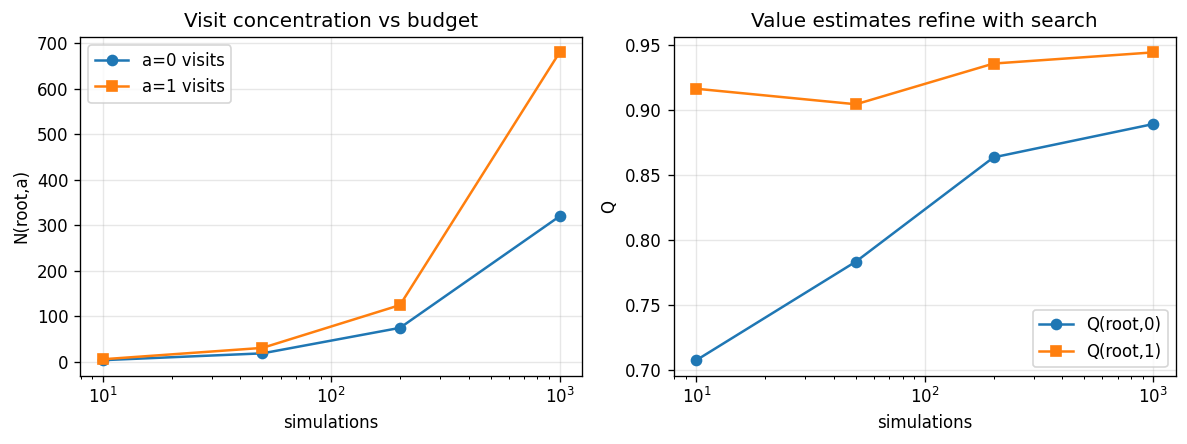

In [3]:
# ── Visualize search focusing on good action at root ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
bs = [r[0] for r in rows]
v0 = [r[1].get(0, 0) for r in rows]
v1 = [r[1].get(1, 0) for r in rows]
q0 = [r[2].get(0, 0) for r in rows]
q1 = [r[2].get(1, 0) for r in rows]

axes[0].plot(bs, v0, "o-", label="a=0 visits")
axes[0].plot(bs, v1, "s-", label="a=1 visits")
axes[0].set_xscale("log")
axes[0].set_xlabel("simulations")
axes[0].set_ylabel("N(root,a)")
axes[0].set_title("Visit concentration vs budget")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(bs, q0, "o-", label="Q(root,0)")
axes[1].plot(bs, q1, "s-", label="Q(root,1)")
axes[1].set_xscale("log")
axes[1].set_xlabel("simulations")
axes[1].set_ylabel("Q")
axes[1].set_title("Value estimates refine with search")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("MCTS_A_budget.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Gridworld — Planning Around a Trap

A larger discrete world where greedy 1-step reward is misleading: a **trap** cell looks fine locally but leads to a pit; the optimal path takes a detour.

Start visits: {'U': 31, 'D': 2204, 'L': 31, 'R': 280}
Start Q     : {'U': -0.6751416352948458, 'D': 0.7594646543997493, 'L': -0.6764064081980716, 'R': -0.1888244280788267}
Greedy-by-visits action: D
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]


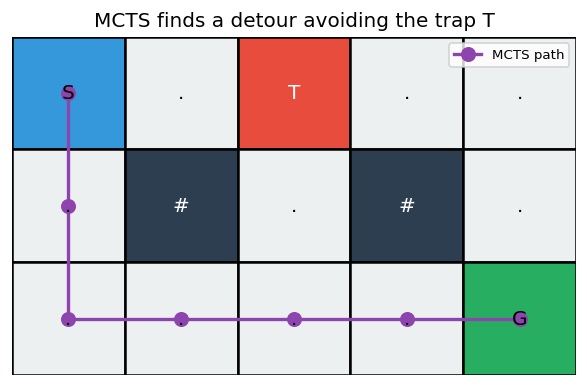

In [4]:
# Grid: S start, G goal, T trap (bad), # wall, . empty
# Coordinates (r,c)
GRID = [
    list("S.T.."),
    list(".#.#."),
    list("....G"),
]
ROWS, COLS = len(GRID), len(GRID[0])
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # U D L R
ACT_NAMES = ["U", "D", "L", "R"]

def find_char(ch):
    for r in range(ROWS):
        for c in range(COLS):
            if GRID[r][c] == ch:
                return (r, c)
    return None

START, GOAL = find_char("S"), find_char("G")
TRAP = find_char("T")

def is_wall(rc):
    r, c = rc
    return not (0 <= r < ROWS and 0 <= c < COLS) or GRID[r][c] == "#"

def grid_step(s, a):
    if s == GOAL:
        return s, 0.0, True
    r, c = s
    dr, dc = ACTIONS[a]
    sp = (r + dr, c + dc)
    if is_wall(sp):
        sp = s
        rwd = -0.05
    elif sp == TRAP:
        rwd = -1.0
    elif sp == GOAL:
        rwd = 1.0
    else:
        rwd = -0.01
    done = sp == GOAL or sp == TRAP
    return sp, rwd, done

def grid_legal(s):
    return list(range(4)) if s not in (GOAL, TRAP) else []

class GridMCTS(MCTS):
    """Reuse MCTS but override env hooks via monkeypatch style methods."""
    pass

# Specialize by rebinding module-level functions used inside MCTS — cleaner: subclass

class MCTSGrid:
    def __init__(self, c_uct=1.5, gamma=0.99, max_depth=30, seed=0):
        self.c = c_uct
        self.gamma = gamma
        self.max_depth = max_depth
        self.rng = np.random.default_rng(seed)
        self.nodes: Dict[Tuple[int,int], Node] = {}

    def get_node(self, s):
        if s not in self.nodes:
            self.nodes[s] = Node(s=s)  # type: ignore
        return self.nodes[s]

    def expand(self, node):
        acts = grid_legal(node.s)
        prior = 1.0 / max(len(acts), 1)
        for a in acts:
            node.edges[a] = EdgeStat(P=prior)
        node.expanded = True

    def uct_select(self, node):
        N_sum = sum(e.N for e in node.edges.values()) + 1
        best_a, best = None, -1e18
        for a, e in node.edges.items():
            score = e.Q + self.c * np.sqrt(np.log(N_sum) / (e.N + 1e-8))
            score += 1e-6 * self.rng.random()
            if score > best:
                best, best_a = score, a
        return best_a

    def rollout(self, s, depth):
        G, disc = 0.0, 1.0
        for _ in range(self.max_depth - depth):
            if s in (GOAL, TRAP):
                break
            a = int(self.rng.choice(grid_legal(s)))
            s, r, done = grid_step(s, a)
            G += disc * r
            disc *= self.gamma
            if done:
                break
        return G

    def simulate(self, s0):
        path = []
        node = self.get_node(s0)
        depth = 0
        s = s0
        while node.expanded and grid_legal(node.s) and depth < self.max_depth:
            a = self.uct_select(node)
            path.append((node.s, a))
            sp, r, done = grid_step(node.s, a)
            depth += 1
            child = self.get_node(sp)
            if done or not child.expanded:
                if not child.expanded and not done:
                    self.expand(child)
                v = r + self.gamma * (0.0 if done else self.rollout(sp, depth))
                self._backup(path, v)
                return v
            node = child
        if not node.expanded:
            self.expand(node)
        v = 0.0 if node.s in (GOAL, TRAP) else self.rollout(node.s, depth)
        self._backup(path, v)
        return v

    def _backup(self, path, leaf_value):
        if not path:
            return
        rewards = [grid_step(s, a)[1] for s, a in path]
        G_list = [0.0] * len(path)
        G_list[-1] = leaf_value
        for i in range(len(path) - 2, -1, -1):
            G_list[i] = rewards[i] + self.gamma * G_list[i + 1]
        for (s, a), G in zip(path, G_list):
            e = self.nodes[s].edges[a]
            e.N += 1
            e.W += G

    def run(self, s0, n_sim):
        self.expand(self.get_node(s0))
        for _ in range(n_sim):
            self.simulate(s0)
        root = self.nodes[s0]
        return {a: e.N for a, e in root.edges.items()}, {a: e.Q for a, e in root.edges.items()}

m = MCTSGrid(seed=1)
visits, qs = m.run(START, n_sim=2000)
print("Start visits:", {ACT_NAMES[a]: visits[a] for a in visits})
print("Start Q     :", {ACT_NAMES[a]: qs[a] for a in qs})
best = max(visits, key=visits.get)
print("Greedy-by-visits action:", ACT_NAMES[best])

# Extract a greedy path by visits for visualization
def extract_path(mcts, s0, max_steps=20):
    path = [s0]
    s = s0
    for _ in range(max_steps):
        if s not in mcts.nodes or s in (GOAL, TRAP):
            break
        node = mcts.nodes[s]
        if not node.edges:
            break
        a = max(node.edges, key=lambda a: node.edges[a].N)
        s, _, done = grid_step(s, a)
        path.append(s)
        if done:
            break
    return path

path = extract_path(m, START)
print("Path:", path)

# Plot grid + path
fig, ax = plt.subplots(figsize=(5, 3.5))
color_map = {"S": "#3498DB", "G": "#27AE60", "T": "#E74C3C", "#": "#2C3E50", ".": "#ECF0F1"}
for r in range(ROWS):
    for c in range(COLS):
        ch = GRID[r][c]
        ax.add_patch(plt.Rectangle((c, ROWS-1-r), 1, 1, facecolor=color_map[ch],
                                   edgecolor="k", lw=1.5))
        ax.text(c+0.5, ROWS-1-r+0.5, ch, ha="center", va="center", fontsize=12,
                color="white" if ch in "#T" else "black")
xs = [c+0.5 for r, c in path]
ys = [ROWS-1-r+0.5 for r, c in path]
ax.plot(xs, ys, "o-", color="#8E44AD", lw=2, ms=8, label="MCTS path")
ax.set_xlim(0, COLS); ax.set_ylim(0, ROWS)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("MCTS finds a detour avoiding the trap T")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("MCTS_B_gridworld.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. PUCT with a Prior Policy — AlphaZero-style

When a network provides $P(a\mid s)$ and $v(s)$, search becomes much more sample-efficient. Even a **hand-crafted heuristic prior** that slightly prefers moving toward the goal demonstrates the effect.

budget   20 | UCT goal=0.0 path=[(0, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0), (1, 0)] | PUCT goal=0.0 path=[(0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0)]
budget   50 | UCT goal=0.0 path=[(0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0)] | PUCT goal=0.0 path=[(0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0)]


budget  100 | UCT goal=0.0 path=[(0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0)] | PUCT goal=0.0 path=[(0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0), (0, 1), (0, 0)]


budget  200 | UCT goal=0.0 path=[(0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0), (1, 0), (0, 0)] | PUCT goal=1.0 path=[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]


budget  500 | UCT goal=1.0 path=[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)] | PUCT goal=1.0 path=[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]


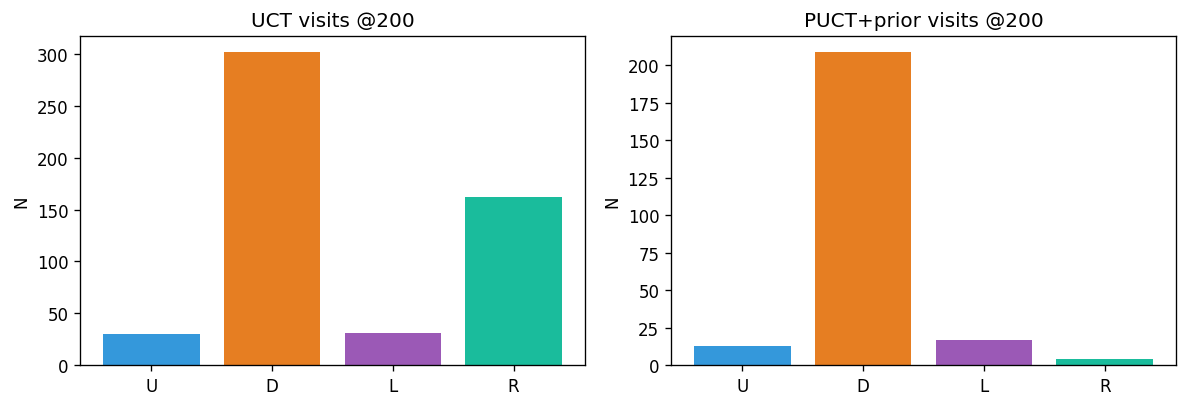

In [5]:
def goal_prior(s):
    """Heuristic prior: soft preference for actions reducing Manhattan distance to goal."""
    if s in (GOAL, TRAP):
        return np.ones(4) / 4
    dist = []
    for a in range(4):
        sp, _, _ = grid_step(s, a)
        d = abs(sp[0] - GOAL[0]) + abs(sp[1] - GOAL[1])
        dist.append(d)
    # lower distance -> higher prior
    logits = -np.array(dist, dtype=float)
    logits = logits - logits.max()
    p = np.exp(logits)
    return p / p.sum()

class MCTSPuct(MCTSGrid):
    def __init__(self, c_puct=1.5, **kwargs):
        super().__init__(**kwargs)
        self.c = c_puct  # reuse field as c_puct

    def expand(self, node):
        acts = grid_legal(node.s)
        prior = goal_prior(node.s)
        for a in acts:
            node.edges[a] = EdgeStat(P=float(prior[a]))
        node.expanded = True

    def uct_select(self, node):  # PUCT
        N_sum = sum(e.N for e in node.edges.values()) + 1
        best_a, best = None, -1e18
        for a, e in node.edges.items():
            score = e.Q + self.c * e.P * np.sqrt(N_sum) / (1 + e.N)
            score += 1e-6 * self.rng.random()
            if score > best:
                best, best_a = score, a
        return best_a

def compare_sample_efficiency():
    budgets = [20, 50, 100, 200, 500]
    uct_success, puct_success = [], []
    for b in budgets:
        # success = path reaches goal without trap
        u = MCTSGrid(seed=0)
        u.run(START, b)
        pu = MCTSPuct(seed=0)
        pu.run(START, b)
        path_u = extract_path(u, START)
        path_p = extract_path(pu, START)
        uct_success.append(float(path_u[-1] == GOAL and TRAP not in path_u))
        puct_success.append(float(path_p[-1] == GOAL and TRAP not in path_p))
        print(f"budget {b:4d} | UCT goal={uct_success[-1]} path={path_u} | PUCT goal={puct_success[-1]} path={path_p}")
    return budgets, uct_success, puct_success

budgets, uct_s, puct_s = compare_sample_efficiency()

# Visit distribution at root for fixed budget
u = MCTSGrid(seed=2); u.run(START, 200)
p = MCTSPuct(seed=2); p.run(START, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, agent, title in [(axes[0], u, "UCT visits @200"), (axes[1], p, "PUCT+prior visits @200")]:
    root = agent.nodes[START]
    ns = [root.edges[a].N if a in root.edges else 0 for a in range(4)]
    ax.bar(ACT_NAMES, ns, color=["#3498DB", "#E67E22", "#9B59B6", "#1ABC9C"])
    ax.set_title(title); ax.set_ylabel("N")
plt.tight_layout()
plt.savefig("MCTS_C_puct_prior.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. From AlphaGo to MuZero — Where World Models Enter

| System | What is known | What search uses |
|---|---|---|
| AlphaGo | Rules of Go (true simulator) | MCTS + policy/value nets |
| AlphaZero | Perfect simulator of game rules | PUCT + self-play |
| **MuZero** | **No rules given** | Learned model $g_\theta$ of latent dynamics + reward; search in latent space |
| Dreamer | Learned world model | Imagination MPC / actor-critic in latent rollouts |

**MuZero model (schematic):**

$$
\begin{aligned}
h_0 &= h_\theta(o_1,\ldots,o_t) && \text{representation} \\
r_k, h_k &= g_\theta(h_{k-1}, a_k) && \text{dynamics + reward} \\
p_k, v_k &= f_\theta(h_k) && \text{prediction (policy, value)}
\end{aligned}
$$

MCTS runs entirely in latent space $h_k$ — no need to render pixels during search.

**Link to this repo:**
- Phase 0–5: geometry of dynamics & chaos (when rollouts are trustworthy).  
- Phase 1–3: interventions $\mathrm{do}(a)$ as the semantics of a simulated action.  
- Phase 4: SSM / Mamba as efficient latent dynamics $h_k = \mathrm{SSM}(h_{k-1}, a_k)$.  
- Phase 6 (here): search that uses the model.  
- Phase 7: learn the model from raw observation streams (JEPA / Dreamer).

## 6. Planning as Causal Intervention Sequences

A plan $a_{1:H}$ is a sequence of interventions. The quantity MCTS estimates is roughly

$$
Q(s, a) \approx \mathbb{E}\!\left[\sum_{k=0}^{H-1} \gamma^k R(s_k, a_k) \;\middle|\; s_0=s, a_0=a,\; \mathrm{do}(a_{1:H})\sim\text{tree policy}\right].
$$

This is **not** the observational conditional "what reward usually co-occurs with action tokens in the dataset." Offline RL + imitation fail when $\mathrm{do}(a)$ shifts the state distribution (confounding, delusional plans). World models that support intervention — structural / simulator / latent dynamics trained with actions as inputs — are the right substrate for MCTS.

Observational  Q(a=0)=0.373  Q(a=1)=1.065  -> prefers a=1
Interventional Q(a=0)=0.252  Q(a=1)=1.251  -> prefers a=1


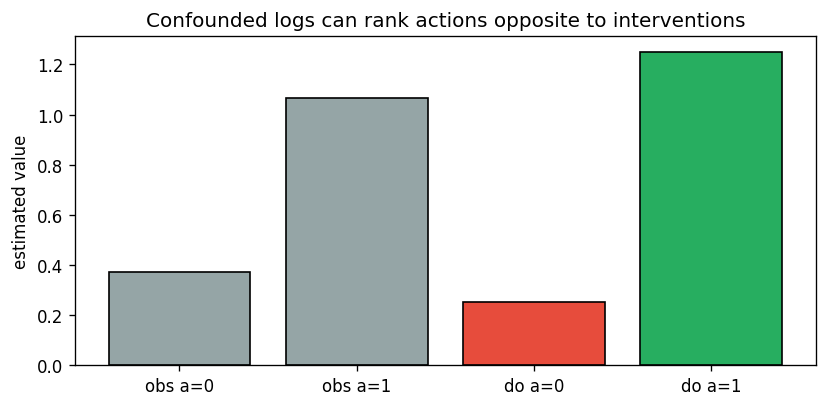

In [6]:
# ── Illustrative: observational vs interventional "policy value" mismatch ──
# Toy bandit with confounder: high context -> people chose action 0 historically,
# but action 1 is actually better when we intervene.

rng = np.random.default_rng(0)
n = 5000
context = rng.integers(0, 2, size=n)  # 0 low, 1 high
# historical logging policy: prefer a=0 when context=1
prob_a0 = np.where(context == 1, 0.9, 0.3)
a = (rng.random(n) > prob_a0).astype(int)  # 1 = action 1
# true reward: action 1 better; plus context effect
r = 0.5 * context + 1.0 * a + rng.normal(0, 0.1, size=n)

# Observational estimates E[r|a]
obs_q0 = r[a == 0].mean()
obs_q1 = r[a == 1].mean()
# Interventional: force a (randomize)
r_do0 = 0.5 * context + 0.0 + rng.normal(0, 0.1, size=n)
r_do1 = 0.5 * context + 1.0 + rng.normal(0, 0.1, size=n)
print(f"Observational  Q(a=0)={obs_q0:.3f}  Q(a=1)={obs_q1:.3f}  -> prefers a={int(obs_q1>obs_q0)}")
print(f"Interventional Q(a=0)={r_do0.mean():.3f}  Q(a=1)={r_do1.mean():.3f}  -> prefers a={int(r_do1.mean()>r_do0.mean())}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(["obs a=0", "obs a=1", "do a=0", "do a=1"],
       [obs_q0, obs_q1, r_do0.mean(), r_do1.mean()],
       color=["#95A5A6", "#95A5A6", "#E74C3C", "#27AE60"], edgecolor="k")
ax.set_ylabel("estimated value")
ax.set_title("Confounded logs can rank actions opposite to interventions")
plt.tight_layout()
plt.savefig("MCTS_D_confounded_Q.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Concept Map

```
Look-ahead Reasoning
│
├── MDP: Q*(s,a) = R + γ E[max Q*]
│
├── MCTS loop
│   ├── Selection (UCT / PUCT)
│   ├── Expansion
│   ├── Evaluation (rollout or v_θ)
│   └── Backup (update N, W, Q)
│
├── Priors
│   ├── Uniform → plain UCT
│   └── Policy network P(a|s) → AlphaZero PUCT
│
├── Models for simulation
│   ├── True rules (AlphaGo)
│   ├── Learned latent model (MuZero)
│   └── SSM / Dreamer imagination rollouts
│
└── Causality
    ├── Simulated action = do(a)
    └── Offline observational Q can be confounded
```

---

## 8. Summary Table

| Concept | Formula / rule | Role |
|---|---|---|
| UCT | $Q + c\sqrt{\ln N / n_a}$ | Explore–exploit in tree |
| PUCT | $Q + c P \sqrt{N}/(1+n_a)$ | Guide search with prior |
| Backup | $N \mathrel{+}=1,\; W \mathrel{+}= G$ | Value accumulation |
| MuZero dynamics | $h_k=g(h_{k-1},a_k)$ | Search without emulator |
| Intervention | $\mathrm{do}(a)$ in model | True planning semantics |

---

## 9. References

- Kocsis & Szepesvári (2006) — Bandit based Monte-Carlo Planning (UCT).
- Browne et al. (2012) — A Survey of Monte Carlo Tree Search Methods.
- Silver et al. (2016) — Mastering the game of Go with deep neural networks and tree search.
- Silver et al. (2017) — Mastering Chess and Shogi by Self-Play (AlphaZero).
- Schrittwieser et al. (2020) — MuZero.
- Hafner et al. — DreamerV3 (imagination-based RL).

---

## 10. Exercises

1. Set $c_{\mathrm{uct}}=0$ (pure greedy $Q$). Does search still find the grid detour with 2000 sims?  
2. Replace random rollouts by a heuristic value: $v(s)=-\mathrm{Manhattan}(s,\mathrm{goal})$. How many sims to stable good path?  
3. Implement action masking walls inside priors (zero $P$ on noop-into-wall) and re-run PUCT.  
4. (Bridge) Swap the true `grid_step` for a deliberately wrong model (trap reward 0). Watch MCTS plan into the trap — model bias.  
5. Write a 10-line PDDL-like description of the grid (predicates `at`, `wall`, `goal`) and list applicable actions — symbolic planning contrast.